In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import pandas as pd

In [3]:
def hill_response(dose, ec50, hill_coefficient=1, e_max=1.0):
    """
    Calculate the Hill dose-response.

    Parameters:
    - dose: float or array-like, dose of the substance
    - ec50: float, dose at which 50% of max response is achieved
    - hill_coefficient: float, describes steepness (default: 1)
    - e_max: float, max response (default: 1.0)

    Returns:
    - response: float or array-like, proportion of max response
    """
    response = (e_max * dose**hill_coefficient) / (ec50**hill_coefficient + dose**hill_coefficient)
    return response

In [4]:
response = hill_response(dose=25, ec50=5, hill_coefficient=1)
print(f"Response: {response:.3f}")

Response: 0.833


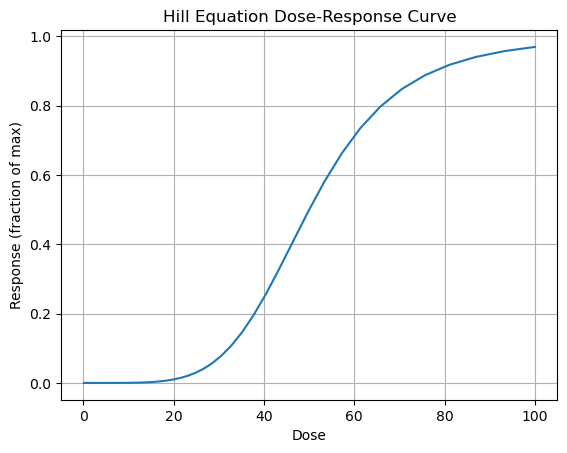

In [5]:

doses = np.logspace(-1, 2, 100)  # from 0.1 to 100
responses = hill_response(doses, ec50=50, hill_coefficient=5)

plt.plot(doses, responses)
#plt.xscale('log')
plt.xlabel("Dose")
plt.ylabel("Response (fraction of max)")
plt.title("Hill Equation Dose-Response Curve")
plt.grid(True)
plt.show()

Fitted EC50: 19.19
Fitted Hill coefficient: 5.00
Fitted E_max: 1.07


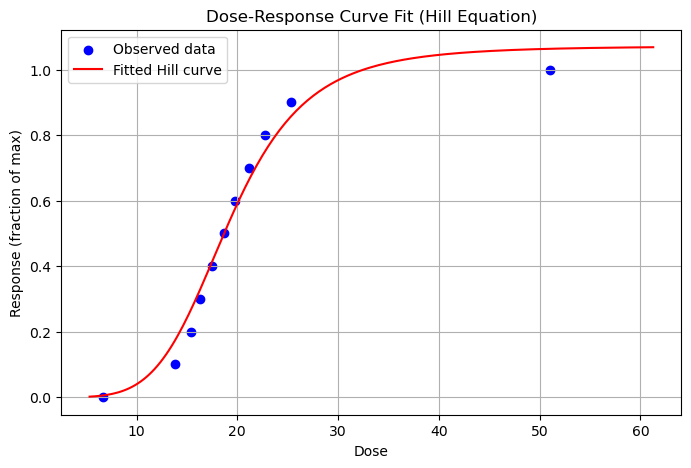

In [6]:
## Estimated dose response curve
dose = np.array([6.67, 13.8, 15.41, 16.33, 17.48, 18.63, 19.78, 21.16, 22.77, 25.3, 51.06])
effect_percent = np.array([0.001, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99.999])
effect = effect_percent / 100.0  # convert to fraction

# Hill equation definition
def hill_equation(dose, ec50, hill_coefficient, e_max):
    return (e_max * dose**hill_coefficient) / (ec50**hill_coefficient + dose**hill_coefficient)

# Fit the curve
popt, pcov = curve_fit(hill_equation, dose, effect, bounds=([0, 0, 0], [np.inf, 5, 1.5]))

# Extract fitted parameters
ec50_fit, hill_fit, emax_fit = popt
print(f"Fitted EC50: {ec50_fit:.2f}")
print(f"Fitted Hill coefficient: {hill_fit:.2f}")
print(f"Fitted E_max: {emax_fit:.2f}")

# Plot
dose_range = np.linspace(min(dose)*0.8, max(dose)*1.2, 200)
fit_response = hill_equation(dose_range, *popt)

plt.figure(figsize=(8,5))
plt.scatter(dose, effect, color='blue', label='Observed data')
plt.plot(dose_range, fit_response, color='red', label='Fitted Hill curve')
plt.xlabel('Dose')
plt.ylabel('Response (fraction of max)')
plt.title('Dose-Response Curve Fit (Hill Equation)')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
## Fitted params
print(f"Fitted EC50: {ec50_fit:.2f}")
print(f"Fitted Hill coefficient: {hill_fit:.2f}")
print(f"Fitted E_max: {emax_fit:.2f}")

likelihood = hill_equation(22, ec50_fit, hill_fit, emax_fit)
print(f"Chance of illness: {likelihood:.3f}")

Fitted EC50: 19.19
Fitted Hill coefficient: 5.00
Fitted E_max: 1.07
Chance of illness: 0.712


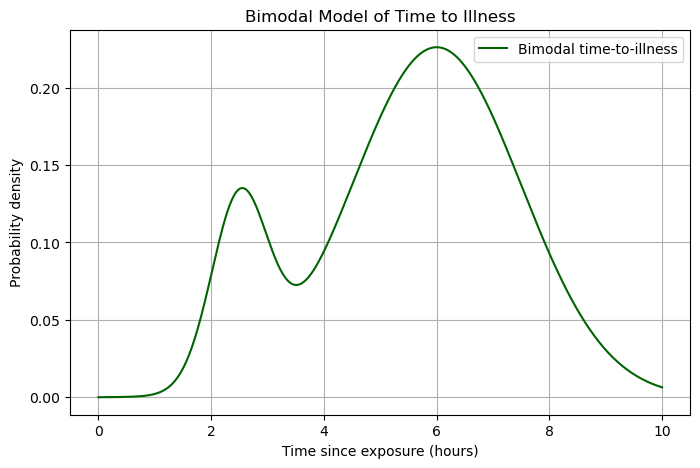

In [8]:

# Parameters for the bimodal function
mu1, sigma1, weight1 = 2.5, 0.5, 0.15
mu2, sigma2, weight2 = 6.0, 1.5, 0.85

# Time range in hours
t = np.linspace(0, 10, 500)

# Define the bimodal probability density function
def bimodal_pdf(t, mu1, sigma1, w1, mu2, sigma2, w2):
    return w1 * norm.pdf(t, mu1, sigma1) + w2 * norm.pdf(t, mu2, sigma2)

# Compute PDF
pdf = bimodal_pdf(t, mu1, sigma1, weight1, mu2, sigma2, weight2)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, pdf, label='Bimodal time-to-illness', color='darkgreen')
plt.xlabel("Time since exposure (hours)")
plt.ylabel("Probability density")
plt.title("Bimodal Model of Time to Illness")
plt.grid(True)
plt.legend()
plt.show()

In [9]:
def sample_bimodal(n_samples=1,
                   mu1=2.5, sigma1=0.6, weight1=0.4,
                   mu2=6.0, sigma2=1.0, weight2=0.6):
    """
    Sample random values from a bimodal distribution defined by two Gaussians.

    Parameters:
    - n_samples: int, number of random values to generate
    - mu1, sigma1: mean and std dev of the first peak
    - weight1: weight of the first peak (between 0 and 1)
    - mu2, sigma2: mean and std dev of the second peak
    - weight2: weight of the second peak (1 - weight1)

    Returns:
    - samples: numpy array of generated values
    """
    assert np.isclose(weight1 + weight2, 1.0), "Weights must sum to 1"
    
    # Choose which component each sample comes from
    components = np.random.choice([1, 2], size=n_samples, p=[weight1, weight2])

    # Preallocate samples
    samples = np.zeros(n_samples)

    # Sample from corresponding Gaussian
    samples[components == 1] = np.random.normal(mu1, sigma1, size=np.sum(components == 1))
    samples[components == 2] = np.random.normal(mu2, sigma2, size=np.sum(components == 2))

    return samples

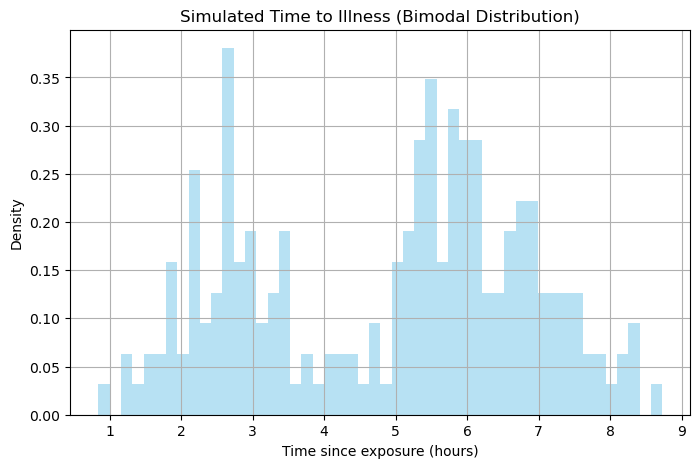

In [10]:
# Generate 10,000 samples
samples = sample_bimodal(n_samples=200)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='skyblue')
plt.xlabel("Time since exposure (hours)")
plt.ylabel("Density")
plt.title("Simulated Time to Illness (Bimodal Distribution)")
plt.grid(True)
plt.show()

# Outcome calculations for Sim

In [11]:
data_date = '2025-07-24'
ver = '-clus1'
#dd_under = data_date.replace('-','_')
sim_data_file_stem = f"../../chem-poison-godot-data/{data_date}/"
act_data_file_name = f"activities_from_output_{data_date}{ver}.csv"
pe_data_file_name = f"poison_exchange_from_output_{data_date}{ver}.csv"
activity_file = sim_data_file_stem+act_data_file_name
poisonexchg_file = sim_data_file_stem+pe_data_file_name

In [22]:
pe = pd.read_csv(poisonexchg_file,parse_dates=['clock'])
pe.sample(3)

,Unnamed: 0,oid,oid_poison_end,oid_poison_start,pid,pid_poison_end,pid_poison_start,time,hour,minute,seconds,clock
4191,8543,/root/Main/Map/Level1/WaterCoolerContainer/Wat...,0.169664,0.358669,1582825,0.308061,0.119056,47751.666666,13.264352,0.0,0.0,2025-06-26 13:15:51.666666472
183,709,/root/Main/Map/Level1/CubicleContainer/Cubicle190,0.000000,0.000000,5964497,0.000000,0.000000,25249.888889,7.013858,0.0,0.0,2025-06-26 07:00:49.888888899
5166,10642,/root/Main/Map/Level1/CubicleContainer/Cubicle241,0.014999,0.014999,1731735,1.093860,1.093860,57665.666666,16.018241,0.0,0.0,2025-06-26 16:01:05.666666328


In [23]:
health = pe[pe.pid_poison_end>0.00][['pid','pid_poison_end','clock']].sort_values(['pid','clock'])
health

,pid,pid_poison_end,clock
1274,211964,0.000719,2025-06-26 08:45:51.888888910
2284,211964,0.000719,2025-06-26 10:01:03.666666642
2608,211964,0.385220,2025-06-26 11:45:24.777777662
2965,211964,0.269654,2025-06-26 12:00:36.777777649
3974,211964,0.378604,2025-06-26 13:09:40.999999811
...,...,...,...
4822,6298914,2.811718,2025-06-26 15:14:11.222221924
4906,6298914,2.811718,2025-06-26 15:17:09.666666366
4738,6298914,2.811718,2025-06-26 15:17:31.222221921
5551,6298914,2.811718,2025-06-26 17:07:36.555555159


In [24]:
health.dtypes

pid                        int64
pid_poison_end           float64
clock             datetime64[ns]
dtype: object

In [130]:
##  Simple approach for each individual change, use the end poison level to calculate a probability.

health['prob_ill'] = health.pid_poison_end.apply(lambda x: hill_equation(x, ec50_fit, hill_fit, emax_fit))

In [26]:
## More refined over time approach, take max poison over time period X and calculate probabilty

resampling_time = '60T'
for pid in health.pid.unique()[1:3]:
    
    he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()
    print(he)

                          pid  pid_poison_end
clock                                        
2025-06-26 08:00:00  240943.0        0.484566
2025-06-26 09:00:00  240943.0        0.357815
2025-06-26 10:00:00       NaN             NaN
2025-06-26 11:00:00       NaN             NaN
2025-06-26 12:00:00  240943.0        0.507481
2025-06-26 13:00:00  240943.0        0.507481
2025-06-26 14:00:00       NaN             NaN
2025-06-26 15:00:00  240943.0        0.996387
2025-06-26 16:00:00  240943.0        0.697471
2025-06-26 17:00:00  240943.0        0.644319
                          pid  pid_poison_end
clock                                        
2025-06-26 07:00:00  253257.0        2.234320
2025-06-26 08:00:00  253257.0        1.568785
2025-06-26 09:00:00       NaN             NaN
2025-06-26 10:00:00       NaN             NaN
2025-06-26 11:00:00  253257.0        1.568785
2025-06-26 12:00:00       NaN             NaN
2025-06-26 13:00:00  253257.0        1.568785
2025-06-26 14:00:00       NaN     

/tmp/ipykernel_534442/1488150237.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()
/tmp/ipykernel_534442/1488150237.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  he = health[health.pid == pid].set_index('clock').resample(resampling_time).max()


In [131]:
import random
def determine_illness(probability,seed=None):
    """
    Given a probability between 0 and 1, returns True (ill) or False (not ill)
    based on a random draw.
    """
    if seed is not None:
        random.seed(seed)
    
    if random.random() < probability:
        outcome = "Ill"
        time_to_symptom = sample_bimodal()[0]
    else:
        outcome = "Not Ill"
        time_to_symptom = 0.0
    
    return outcome,time_to_symptom

<Axes: >

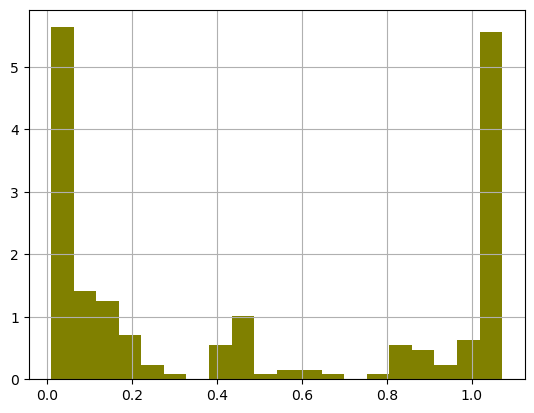

In [132]:
health[health.prob_ill > 0.01].prob_ill.hist(bins=20,density=True, color='olive')

In [133]:
rand_seed = 54321123

health[['outcome','hours_to_symptom']] = health.apply(lambda x: (determine_illness(x['prob_ill'],seed=rand_seed)),
                                                      axis=1,result_type='expand')
health['time_ill'] = pd.to_datetime(health.clock) + pd.to_timedelta(health['hours_to_symptom'], unit='h')

## Determine the final outcomes from the independent samples of outcomes
#### Take the independent sampling of illness and time to illness and find the first time someone is ill and use that sample as the final 

In [134]:
final_outcome = health[health.outcome == 'Ill'].groupby('pid').time_ill.min().reset_index()
#final_outcome.columns = ['pid','time_ill']
final_outcome

,pid,time_ill
0,313397,2025-06-26 09:24:02.257994733
1,380037,2025-06-26 08:43:42.002245561
2,1434928,2025-06-26 08:46:37.700595240
3,1452368,2025-06-26 09:03:42.370811877
4,1603375,2025-06-26 08:20:55.121374068
5,1689433,2025-06-26 07:54:15.075108688
6,1888780,2025-06-26 10:07:50.048811329
7,3422610,2025-06-26 14:37:55.693644746
8,3486012,2025-06-26 09:41:41.932477194
9,4305902,2025-06-26 12:26:59.086608856


Text(0.5, 0, 'Hour of the day')

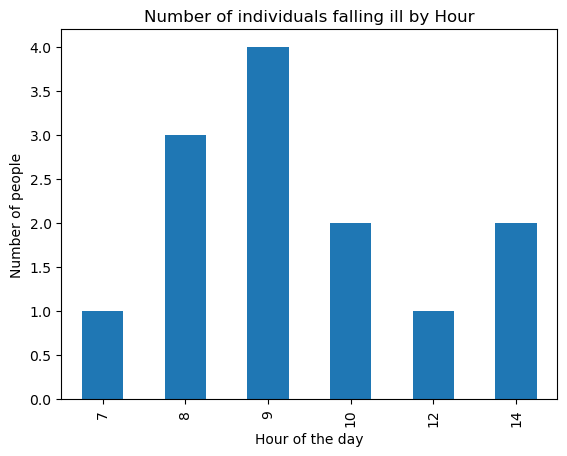

In [135]:
ax = final_outcome.time_ill.dt.hour.value_counts().sort_index().plot(kind='bar')
plt.title("Number of individuals falling ill by Hour")
ax.set_ylabel("Number of people")
ax.set_xlabel("Hour of the day")

In [136]:
final_outcome.to_csv(f'Health_Outcomes_TimeIll_{data_date+ver}.csv',index=False)

In [138]:
final_outcome = health.groupby('pid').outcome.sum().sort_values().reset_index()
fo = final_outcome[final_outcome['outcome'] > 'Ill']

In [41]:
samples = sample_bimodal(n_samples=fo.shape[0])

In [42]:
samples

array([6.25309075, 2.54061395, 2.99287551, 5.95330416, 5.58120535,
       5.76724156, 4.09582208, 1.5789641 , 6.82918939, 7.29451254,
       5.2875392 , 2.24401925, 2.0539063 ])